# 10f — The real-world carbon-pricing landscape

Covers `chap10_pricing1.m`, `pricing2a.m`, `pricing2b.m`, `pricing3.m`,
and `pricing4.m`: World Bank 2025 carbon-tax and ETS price/coverage
tables by scheme, the EU ETS carbon-price time series spliced from two
source vintages, voluntary carbon market prices by project category
(Ecosystem Marketplace), and the top-15 carbon-pricing schemes by
coverage share and revenue.

Three further scripts — `pricing5`, `pricing6`, `pricing7` — are
**data-blocked**: they depend on `chap10_eutl_2023.mat` and/or
`chap10_cdp_icp_2023.mat`/`chap10_coverage_carbon_pricing_2022.mat`,
`.mat` files whose payload is a MATLAB `table` object serialized as an
MCOS opaque type with no Python deserializer and no `.xlsx` fallback
anywhere in the archive (confirmed by direct inspection — see
`chapter10_scoping.md`). Flagged here rather than faked.

The 5 buildable scripts here load real World Bank, EU ETS, and
Ecosystem Marketplace data (all `.mat` in the source, but every one has
a readable `.xlsx` sibling that the source's own prep scripts were built
from — used directly here).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "../../data"
color_green = "#2ca02c"
color_black = "#000000"

def top_schemes_table(df, top_n=33):
    """Faithful port of the shared table-building logic in
    chap10_pricing1.m / pricing2a.m: pick 6 representative years, sort
    schemes by their most recent (2024) price descending (missing prices
    sort last), keep the top `top_n`, and format as a price-by-year table
    with a coverage column."""
    selected_years = [2015, 2020, 2022, 2023, 2024, 2025]
    price_cols = [f"p{y}" for y in selected_years]
    d = df[["Country", *price_cols, "Coverage"]].copy()
    d = d.sort_values("p2024", ascending=False, na_position="last").head(top_n)
    d = d.rename(columns={f"p{y}": str(y) for y in selected_years})
    d["Coverage"] = 100 * d["Coverage"]
    return d.reset_index(drop=True)

## 1. Carbon tax schemes worldwide (`chap10_pricing1.m`)

The top 33 national/subnational carbon **tax** schemes (World Bank
Carbon Pricing Dashboard 2025), ranked by their 2024 price, showing
price evolution across six snapshot years and current emissions
coverage.

In [2]:
T_tax = pd.read_excel(f"{DATA_DIR}/chap10_world_bank_carbon_price_2025.xlsx", sheet_name="Tax")
table_tax = top_schemes_table(T_tax)
display(table_tax.round(2))

,Country,2015,2020,2022,2023,2024,2025,Coverage
0,Uruguay,NaN,NaN,137.30,155.87,167.17,158.76,5.0
1,Switzerland,61.96,99.44,129.86,130.81,132.12,136.04,35.0
2,Liechtenstein,37.17,99.44,129.86,130.81,132.12,136.04,72.0
3,Sweden,129.81,119.43,129.89,125.56,123.70,144.62,40.0
4,Norway,68.32,63.28,96.31,94.49,107.78,133.92,14.0
5,Finland,62.38,84.21,85.10,83.74,99.98,66.89,39.0
6,Netherlands,NaN,NaN,46.14,60.83,71.48,94.83,1.0
7,Canada,NaN,21.10,39.96,48.03,58.94,NaN,NaN
8,British Columbia,23.79,28.14,39.96,48.03,58.94,NaN,NaN
9,Northwest Territories,NaN,14.07,31.97,48.03,58.94,NaN,NaN


## 2. Emissions Trading Systems worldwide (`chap10_pricing2a.m`)

The same table construction applied to the World Bank's **ETS**
(cap-and-trade) sheet instead of the tax sheet.

In [3]:
T_ets = pd.read_excel(f"{DATA_DIR}/chap10_world_bank_carbon_price_2025.xlsx", sheet_name="ETS")
table_ets = top_schemes_table(T_ets)
display(table_ets.round(2))

,Country,2015,2020,2022,2023,2024,2025,Coverage
0,EU,7.69,18.54,86.53,96.30,61.30,70.37,40.0
1,Switzerland,12.91,19.85,65.59,93.81,59.17,64.75,13.0
2,Alberta,11.89,21.10,39.96,48.03,58.94,66.21,59.0
3,Canada,NaN,NaN,39.96,48.03,58.94,66.21,3.0
4,Ontario,NaN,NaN,31.97,48.03,58.94,66.21,26.0
5,Nova Scotia,NaN,NaN,23.10,20.87,58.94,66.21,36.0
6,New Brunswick,NaN,NaN,39.96,48.03,58.94,66.21,54.0
7,British Columbia,NaN,NaN,19.98,18.47,58.94,66.21,26.0
8,Newfoundland and Labrador,NaN,NaN,39.96,48.03,58.94,66.21,36.0
9,Saskatchewan,NaN,NaN,39.96,48.03,58.94,NaN,NaN


## 3. EU ETS carbon price, 2008-2025 (`chap10_pricing2b.m`)

The source script's own prep data (`chap10_eu_ets_carbon_price.xlsx`)
ships four independently-sourced EU ETS price vintages covering
overlapping date ranges. This section reproduces the exact splice the
source performs: **Source 2** for dates before 2023-01-01, then
**Source 4** for dates from 2023-01-01 onward (each source series is
more reliable/complete over its respective era), sampling every 3rd
observation before charting — a faithful, if slightly unusual, way of
stitching together a single long price history from imperfect
overlapping sources.

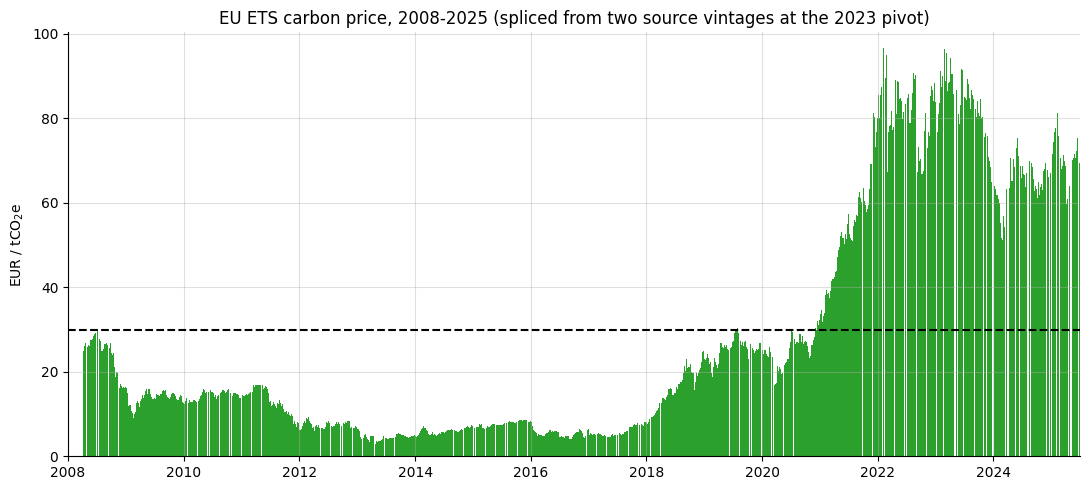

In [4]:
xl = pd.ExcelFile(f"{DATA_DIR}/chap10_eu_ets_carbon_price.xlsx")
src2 = pd.read_excel(xl, sheet_name="Source 2", header=0, names=["Date", "Price"]).dropna()
src4 = pd.read_excel(xl, sheet_name="Source 4", header=0, names=["Date", "Price"]).dropna()
src2["Date"] = pd.to_datetime(src2["Date"])
src4["Date"] = pd.to_datetime(src4["Date"])
src2 = src2.sort_values("Date")
src4 = src4.sort_values("Date")

pivot_date = pd.Timestamp("2023-01-01")
part1 = src2[src2["Date"] < pivot_date]
part2 = src4[src4["Date"] >= pivot_date]
spliced = pd.concat([part1, part2], ignore_index=True).sort_values("Date").reset_index(drop=True)
spliced = spliced.iloc[::3].reset_index(drop=True)  # every 3rd observation, as in the source

fig, ax = plt.subplots(figsize=(11, 5))
width = float(np.median(np.diff(spliced["Date"].values)) / np.timedelta64(1, "D")) * 0.9
ax.bar(spliced["Date"], spliced["Price"], width=width, color=color_green)
ax.axhline(30, linestyle="--", color=color_black, lw=1.5)
ax.set_xlim(pd.Timestamp("2008-01-01"), pd.Timestamp("2025-07-01"))
ax.set_ylim(0, 100.35)
ax.set_ylabel("EUR / tCO$_2$e")
ax.grid(True, alpha=0.4)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.set_title("EU ETS carbon price, 2008-2025 (spliced from two source vintages at the 2023 pivot)")
plt.tight_layout()
plt.show()

## 4. Voluntary carbon market prices by category (`chap10_pricing3.m`)

Average transacted price (\$/tCO$_2$e) on the voluntary carbon market
by project category, 2020-2024 (Ecosystem Marketplace). Prices surged
across the board in 2022 before easing back in 2023-2024.

In [5]:
T_price = pd.read_excel(f"{DATA_DIR}/chap10_ecosystem_marketplace_2025.xlsx", sheet_name="Price")
display(T_price.set_index("Category").round(2))

,p2020,p2021,p2022,p2023,p2024
Category,,,,,
Forestry and land use,5.46,5.87,10.14,10.04,9.27
Agriculture,10.38,8.81,11.02,6.51,7.66
Household/community devices,4.08,5.36,8.56,7.71,7.30
Waste disposal,2.80,3.69,7.23,7.46,6.72
Chemical processes,2.15,3.12,5.14,4.10,3.66
Transport,0.64,1.16,4.37,NaN,3.24
Energy efficiency/fuel switching,0.98,2.16,5.39,3.65,3.05
Renewable energy,1.08,2.19,4.16,4.10,2.67
Overall,2.56,4.07,7.37,6.71,6.34


## 5. Top-15 carbon-pricing schemes by coverage share and revenue (`chap10_pricing4.m`)

Ranks the top 15 schemes by their 2024 share of global GHG emissions
covered, alongside the top 15 by 2024 revenue raised (\$bn) — two
different rankings from the same World Bank dataset, side by side.
Also reproduces the source's two summary diagnostics: total emissions
coverage share and total revenue **across every scheme in the
dataset**, not just the top 15 shown in the table.

In [6]:
T_share = pd.read_excel(f"{DATA_DIR}/chap10_world_bank_carbon_price_2025.xlsx", sheet_name="Share")
T_revenue = pd.read_excel(f"{DATA_DIR}/chap10_world_bank_carbon_price_2025.xlsx", sheet_name="Revenue")

top15 = pd.DataFrame({
    "Rank": range(1, 16),
    "Scheme (by coverage share)": T_share["Name"].head(15).values,
    "Share of global GHG emissions (%)": (100 * T_share["x2024"].head(15)).round(2).values,
    "Scheme (by revenue)": T_revenue["Name"].head(15).values,
    "Revenue 2024 ($bn)": (T_revenue["x2024"].head(15) / 1e3).round(2).values,
}).set_index("Rank")
display(top15)

total_share = 100 * T_share["x2024"].sum()
total_revenue = T_revenue["x2024"].dropna().sum() / 1e3
print(f"Total share of global GHG emissions covered by carbon pricing (all {len(T_share)} schemes): {total_share:.2f}%")
print(f"Total global carbon-pricing revenue, 2024 (all schemes with reported data): ${total_revenue:.2f}bn")

,Scheme (by coverage share),Share of global GHG emissions (%),Scheme (by revenue),Revenue 2024 ($bn)
Rank,,,,
1,China national ETS,15.29,EU ETS,41.70
2,EU ETS,2.36,Germany ETS,13.93
3,Japan carbon tax,1.57,Canada federal fuel charge,8.86
4,Korea ETS,1.10,France carbon tax,7.84
5,South Africa carbon tax,0.81,California CaT,4.40
6,Indonesia ETS,0.59,UK ETS,3.25
7,California CaT,0.56,Sweden carbon tax,2.31
8,Mexico ETS,0.54,BC carbon tax,1.89
9,Germany ETS,0.50,Norway carbon tax,1.61


Total share of global GHG emissions covered by carbon pricing (all 91 schemes): 28.58%
Total global carbon-pricing revenue, 2024 (all schemes with reported data): $102.19bn
